In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [16]:
with open("knn_dataset_exercicio_1.csv", "r") as f:
    linhas = f.readlines()

dados = []
for linha in linhas:
    linha = linha.strip().strip('|')
    if '---' in linha:
        continue
    partes = [p.strip() for p in linha.split('|')]
    try:
        dados.append([float(p) for p in partes])
    except ValueError:
        continue

dataset = np.array(dados)

X_train = dataset[:, :2]
y_train = dataset[:, 2].astype(int)

print("Amostra das características (X_train):")
print(X_train[:5])
print("\nAmostra dos rótulos (y_train):")
print(y_train[:5])

Amostra das características (X_train):
[[2000.  500.]
 [2500.  700.]
 [3000.  800.]
 [3200. 1000.]
 [3500. 1200.]]

Amostra dos rótulos (y_train):
[1 1 1 2 2]


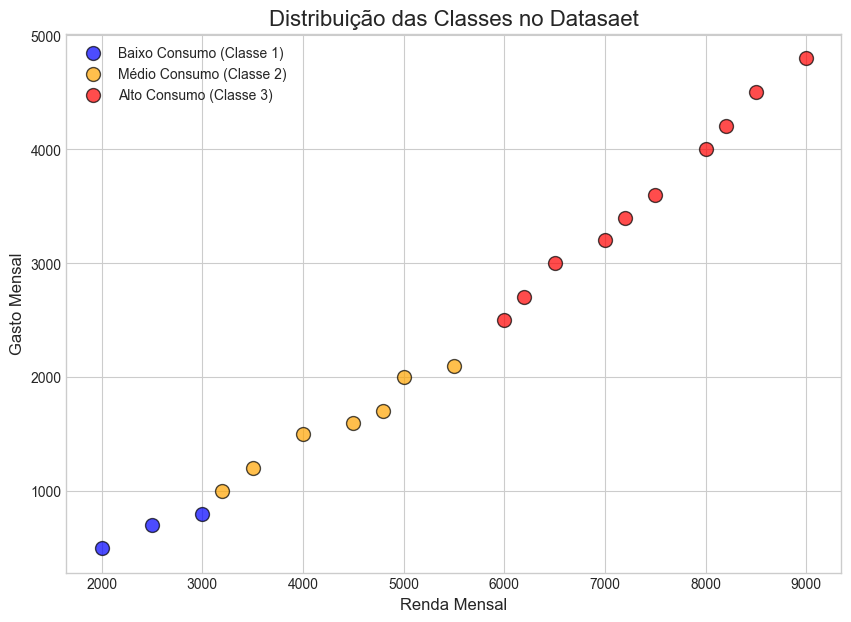

In [17]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10,7))

ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1,1],
           c='blue', s=100, edgecolor='k', alpha=0.7, label='Baixo Consumo (Classe 1)')

ax.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1],
           c='orange', s=100, edgecolor='k', alpha=0.7, label='Médio Consumo (Classe 2)')

ax.scatter(X_train[y_train == 3, 0], X_train[y_train == 3, 1],
           c='red', s=100, edgecolor='k', alpha=0.7, label='Alto Consumo (Classe 3)')

ax.set_title('Distribuição das Classes no Datasaet', fontsize=16)
ax.set_xlabel('Renda Mensal', fontsize=12)
ax.set_ylabel('Gasto Mensal', fontsize=12)
ax.legend()
plt.show()

In [18]:
def calcular_distancia_euclidiana(ponto1, ponto2):
    """Calcula a distância euclidiana entre dois pontos."""
    return np.sqrt(np.sum((ponto1 - ponto2)**2))

def encontrar_vizinhos(X_train, y_train, ponto_teste, k):
    """Encontra os k vizinhos mais próximos de um ponto teste."""
    
    distancias = []
    for i, ponto_treino in enumerate(X_train):
        dist = calcular_distancia_euclidiana(ponto_treino, ponto_teste)
        distancias.append((dist, y_train[i]))

        distancias.sort(key=lambda x: x[0])

    vizinhos = [distancia[1] for distancia in distancias[:k]]
    return vizinhos

In [19]:
def prever_classificacao(vizinhos):
    """Faz a previsão com base no voto marjoritário dos vizinhos"""

    contagem_votos = Counter(vizinhos)
    previsao = contagem_votos.most_common(1)[0][0]
    return previsao

nova_classe = np.array([7000, 200])
k = 5

vizinhos_proximos = encontrar_vizinhos(X_train, y_train, nova_classe, k)
previsao_final = prever_classificacao(vizinhos_proximos)

if previsao_final == 1:
    resultado_texto = "Baixo Consumo"
elif previsao_final == 2:
    resultado_texto = "Médio Consumo"
else:
    resultado_texto = "Alto Consumo"

print(f"A nova classe tem as caracteristicas: {nova_classe}")
print(f"O valor de 'k' escolhido foi: {k}")
print(f"As classes dos vizinhos mais próximos são: {vizinhos_proximos}")
print("-------------------------------------------------------")
print(f"--> Previsão final: A nova classe é classificado como {resultado_texto} (Classe {previsao_final})")


A nova classe tem as caracteristicas: [7000  200]
O valor de 'k' escolhido foi: 5
As classes dos vizinhos mais próximos são: [np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(2)]
-------------------------------------------------------
--> Previsão final: A nova classe é classificado como Médio Consumo (Classe 2)


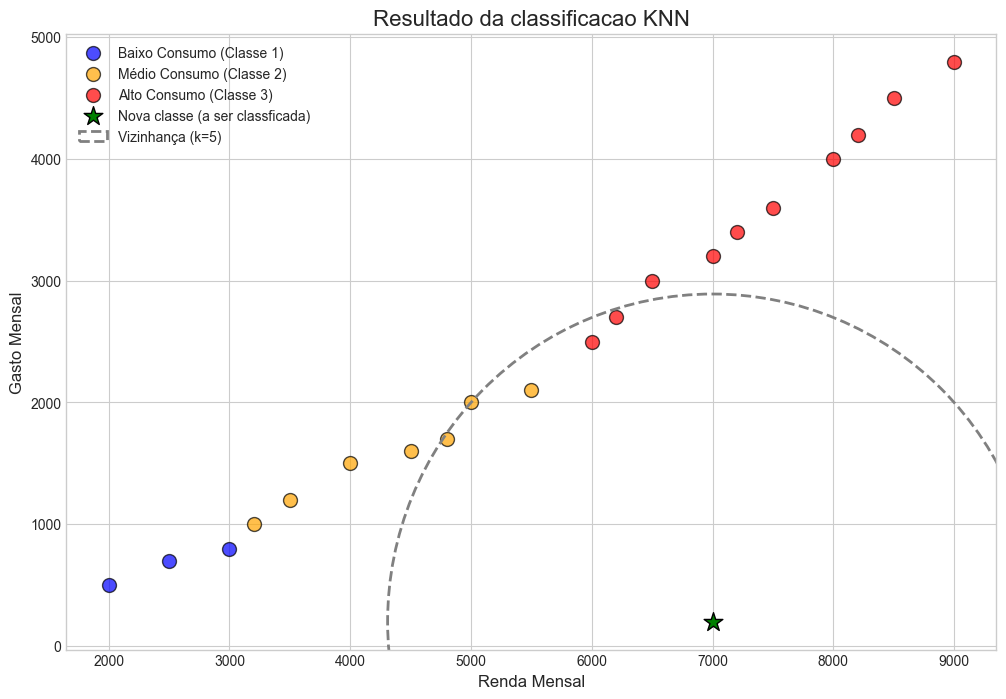

In [20]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1,1],
           c='blue', s=100, edgecolor='k', alpha=0.7, label='Baixo Consumo (Classe 1)')

ax.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1],
           c='orange', s=100, edgecolor='k', alpha=0.7, label='Médio Consumo (Classe 2)')

ax.scatter(X_train[y_train == 3, 0], X_train[y_train == 3, 1],
           c='red', s=100, edgecolor='k', alpha=0.7, label='Alto Consumo (Classe 3)')

ax.scatter(nova_classe[0], nova_classe[1], c='green', s=200,
           edgecolor='k', marker='*', label='Nova classe (a ser classficada)')

indice_vizinhos = np.argsort([calcular_distancia_euclidiana(p, nova_classe) for p in X_train]) [:k]
pontos_vizinhos = X_train[indice_vizinhos]

distancia_maxima = calcular_distancia_euclidiana(nova_classe, pontos_vizinhos[-1])
circulo = plt.Circle(nova_classe, distancia_maxima, color='gray', fill=False,
                     linestyle='--', linewidth=2, label=f'Vizinhança (k={k})')
ax.add_artist(circulo)

ax.set_title('Resultado da classificacao KNN', fontsize=16)
ax.set_xlabel('Renda Mensal', fontsize=12)
ax.set_ylabel('Gasto Mensal', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True)
plt.show()



## a- O KNN conseguiu separar bem os clientes em grupos de consumo (baixo, médio e alto)?

R: Sim, estão bem separados no gráfico, indicando que as variáveis utilizadas permitem identificar um padrão.

## b- Há casos em que clientes com renda alta, mas gasto baixo, podem ser classificados incorretamente? O que isso indica sobre a estratégia de segmentação?

R: Pode ser classificado errado, pois se um cliente de renda alta e baixo gasto estiver cercado por clientes(vizinhos) de baixa renda e baixo gasto, ele poderá ser classificado como baixa renda. Isso indica que a estratégia de segmentação depende fortemente da distribuição dos dados e pode não capturar bem casos atípicos (outliers).

## c- Como a escolha do valor de k influencia na fronteira entre os grupos?

R: A escolha de k define quantos vizinhos influenciam a decisão. Por exemplo, com k = 5, se a maioria dos vizinhos for da classe média, o ponto será classificado como classe média, mesmo que suas características sejam diferentes.